<a href="https://colab.research.google.com/github/devanaraj07-glitch/DBA/blob/main/Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Data Processing

Devana Raj, 32146986

Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/My Drive/northstar_dataset/northstar_dataset/"

In [ ]:
orders = pd.read_csv(base_path + "orders.csv")
deliveries = pd.read_csv(base_path + "deliveries.csv")
complaints = pd.read_csv(base_path + "complaints.csv")
customers = pd.read_csv(base_path + "customers.csv")
drivers = pd.read_csv(base_path + "drivers.csv")
vehicles = pd.read_csv(base_path + "vehicles.csv")

Inspect missing values

In [ ]:
print("Missing Values:")
print(orders.isnull().sum())
print(deliveries.isnull().sum())
print(complaints.isnull().sum())

Missing Values:
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
complaint_id            0
customer_id             0
order_id                0
complaint_type          0
channel                 0
severity                0
created_at              0


Data cleaning

In [ ]:
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].mean()
)

complaints['resolution_days'] = complaints['resolution_days'].fillna(
    complaints['resolution_days'].median()
)

In [ ]:
deliveries.drop_duplicates(inplace=True)
complaints.drop_duplicates(inplace=True)

Feature engineering

In [ ]:
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])

deliveries['delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

In [ ]:
deliveries['delayed'] = deliveries['delivery_duration_hours'] > 4

Merge datasets

In [ ]:
merged = deliveries.merge(
    orders[['order_id', 'service_type']],
    on='order_id'
)

In [ ]:
delay_service = merged.groupby('service_type')['delivery_duration_hours'].mean()
print(delay_service)

service_type
Business     9.172760
Medical      9.977858
Parcel       9.716157
Passenger    9.131791
Retail       9.858577
Name: delivery_duration_hours, dtype: float64


Analysis 1: Delay by service type

In [ ]:
delay_service = merged.groupby('service_type')['delivery_duration_hours'].mean()
print(delay_service)

service_type
Business     9.172760
Medical      9.977858
Parcel       9.716157
Passenger    9.131791
Retail       9.858577
Name: delivery_duration_hours, dtype: float64


Visualize:

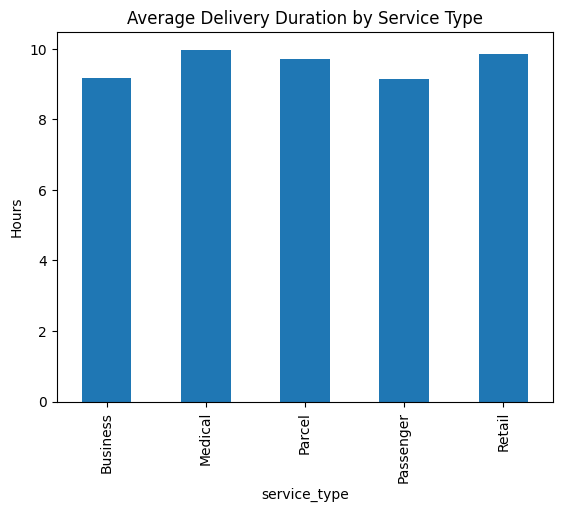

In [ ]:
delay_service.plot(kind='bar')
plt.title('Average Delivery Duration by Service Type')
plt.ylabel('Hours')
plt.show()

Analysis 2: Route override relationship

In [ ]:
override_corr = deliveries[['manual_route_override_count',
                            'delivery_duration_hours']].corr()

print(override_corr)

                             manual_route_override_count  \
manual_route_override_count                     1.000000   
delivery_duration_hours                        -0.013711   

                             delivery_duration_hours  
manual_route_override_count                -0.013711  
delivery_duration_hours                     1.000000  


Visualize:

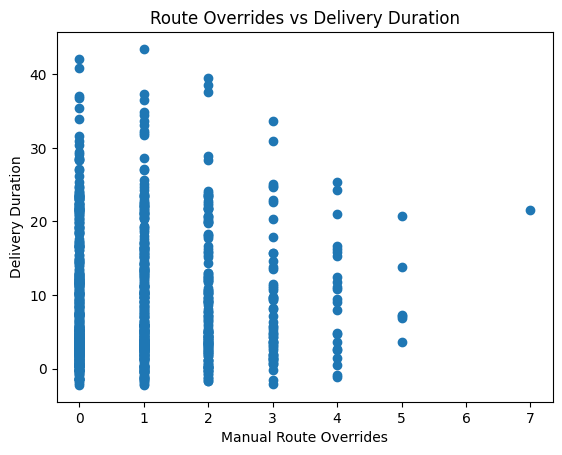

In [ ]:
plt.scatter(
    deliveries['manual_route_override_count'],
    deliveries['delivery_duration_hours']
)
plt.title('Route Overrides vs Delivery Duration')
plt.xlabel('Manual Route Overrides')
plt.ylabel('Delivery Duration')
plt.show()

Analysis 3: Complaint severity distribution

In [ ]:
complaints['severity'].value_counts()

,count
severity,
Medium,172
High,77
Low,71


Visualize

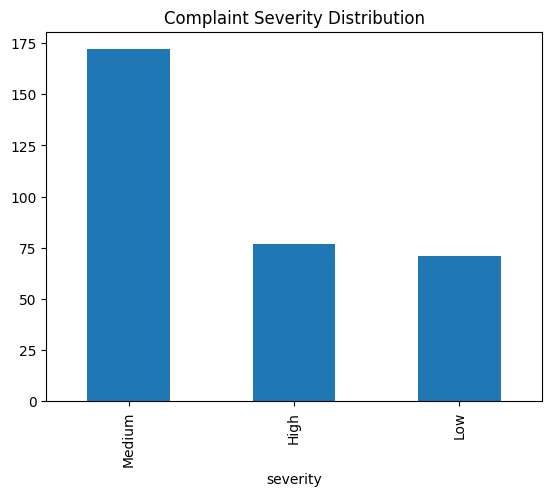

In [ ]:
complaints['severity'].value_counts().plot(kind='bar')
plt.title('Complaint Severity Distribution')
plt.show()

Analysis 4: Vehicle battery health

In [ ]:
vehicles.groupby('maintenance_status')['battery_health_pct'].mean()

,battery_health_pct
maintenance_status,
Active,76.628571
InRepair,76.641667
Scheduled,77.670588


Visualize:


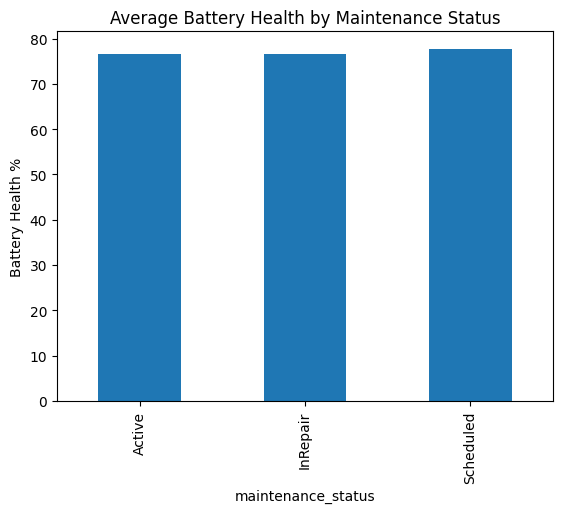

In [ ]:
vehicles.groupby('maintenance_status')['battery_health_pct'].mean().plot(kind='bar')
plt.title('Average Battery Health by Maintenance Status')
plt.ylabel('Battery Health %')
plt.show()

Analysis 5: Customer engagement vs complaints

In [ ]:
cust_comp = complaints.merge(customers, on='customer_id')

cust_comp.groupby('customer_type')['app_engagement_score'].mean()

,app_engagement_score
customer_type,
Consumer,56.757438
Enterprise,58.900000
SME,54.542000


Visualize:

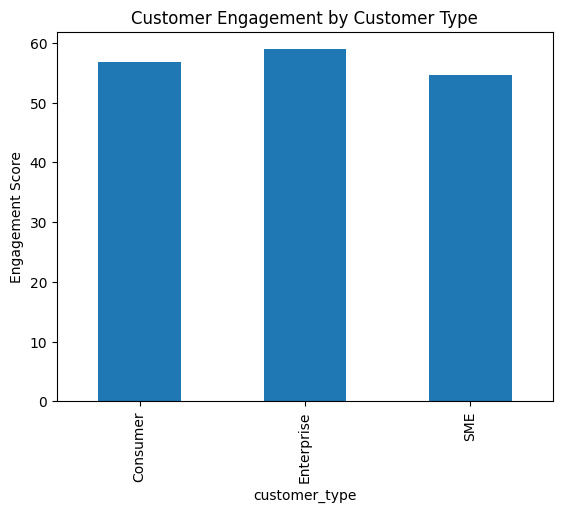

In [ ]:
cust_comp.groupby('customer_type')['app_engagement_score'].mean().plot(kind='bar')
plt.title('Customer Engagement by Customer Type')
plt.ylabel('Engagement Score')
plt.show()

Summary

In [ ]:
print("Total delayed deliveries:", deliveries['delayed'].sum())
print("Average delivery duration:", deliveries['delivery_duration_hours'].mean())

Total delayed deliveries: 612
Average delivery duration: 9.545486064205754
